In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from src.processing import find_pareto_front, create_landscape_from_predictions#, history_to_dataframe
from src.visualization import (display_pareto_fronts3, 
                               display_fitness_landscape_with_2pareto, 
                               gerar_gif_evolucao_nsga2, 
                               display_evolution_of_genotypes, 
                               display_fitness_landscape_with_paretos)
from src.metrics import (calculate_gamma_convergence_metric, print_gamma_metric,
                         calculate_fitness_sum_statistics, print_fitness_sum_statistics,
                         calculate_delta_diversity_metric, print_delta_metric)

from src.nsgaII import run_my_nsga2
from src.ua_sa_nsgaII import run_my_uasa_nsga2

/Users/gmello/Documents/python_venvs/mestrado_estatistica/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
salva_gifs = False

In [3]:
# Parâmetros NSGA-II
config = {
    # definindo o algoritmo
    'population_size': 100,
    'n_generations': 100,
    'k_tournament': 2,
    'crossover_prob': 0.9,
    'crossover_eta': 15,
    'mutation_prob': 1/6,  # 1/n_var
    'mutation_eta': 20,
    'seed': 42,
    'track_progress': True,
    'utiliza_ds_niching': True,
    'pesos_ds_niching': [1, 1],

    # definindo o problema
    'n_objetivos': 2,
    'fitness_cols': ["fitness1", "fitness2"],
    'maximize': False,
    'n_restricoes': 0,

    # definindo o genótipo
    'tamanho_genotipo': 2,
    'limite_inferior': np.array([-5, -5]),
    'limite_superior': np.array([ 5,  5]),
    'tipo_variavel_genotipo': float
}

# Cria array de alphas: 1.0 na geração 0, 0.0 na última geração, variação linear
# Alpha controla exploração (1.0) vs convergência (0.0)
n_gens = config['n_generations']
config['alpha_exploration_rank_distance'] = np.linspace(1.0, 0.0, n_gens)

# Inputs

In [4]:
df_mmf1_previsao   = pd.read_parquet('data/dataframes/MMF1/df_mmf1_previsao.parquet')
df_mmf4_previsao   = pd.read_parquet('data/dataframes/MMF4/df_mmf4_previsao.parquet')
df_bbob16_previsao = pd.read_parquet('data/dataframes/BBOB16/df_bbob16_previsao.parquet')

df_mmf1   = pd.read_parquet('data/dataframes/MMF1/df_mmf1.parquet')
df_mmf4   = pd.read_parquet('data/dataframes/MMF4/df_mmf4.parquet')
df_bbob16 = pd.read_parquet('data/dataframes/BBOB16/df_bbob16.parquet')

print(df_mmf1_previsao.shape)
print(df_mmf4_previsao.shape)

print(df_bbob16_previsao.shape)
display(df_bbob16_previsao.head())

(999504, 12)
(999504, 12)
(999504, 12)


,x_1,x_2,f1,f2,aux,bin_x1,bin_x2,regiao,f1_original,f2_original,f1_predicted,f2_predicted
0,-5.00000,-5.0,8.573109,5.373746,1,0,0,1,8.666895,5.831873,7.425479,5.533093
1,-4.98999,-5.0,9.818128,6.574159,1,0,0,1,8.665178,5.826707,7.425479,5.533093
2,-4.97998,-5.0,9.267276,6.838701,1,0,0,1,8.663448,5.821392,7.425479,5.533093
3,-4.96997,-5.0,7.803139,6.484946,1,0,0,1,8.661705,5.815924,7.425479,5.533093
4,-4.95996,-5.0,7.860431,6.419157,1,0,0,1,8.659949,5.810299,7.425479,5.533093


In [5]:
df_mcmc_mmf1 = pd.read_parquet('data/dataframes/MMF1/df_mmf1_mcmc.parquet').rename(columns={'index_linha': 'id_simulacao'})
df_mcmc_mmf4 = pd.read_parquet('data/dataframes/MMF4/df_mmf4_mcmc.parquet').rename(columns={'index_linha': 'id_simulacao'})
df_mcmc_bbob16 = pd.read_parquet('data/dataframes/BBOB16/df_bbob16_mcmc.parquet').rename(columns={'index_linha': 'id_simulacao'})

df_mcmc_mmf1.sort_values(['regiao', 'id_simulacao'], inplace=True)
df_mcmc_mmf4.sort_values(['regiao', 'id_simulacao'], inplace=True)
df_mcmc_bbob16.sort_values(['regiao', 'id_simulacao'], inplace=True)

config['n_simulations'] = df_mcmc_mmf1['id_simulacao'].max() + 1
print('n_simulations: ', config['n_simulations'])

print(df_mcmc_mmf1.shape)
print(df_mcmc_mmf4.shape)
print(df_mcmc_bbob16.shape)

df_mcmc_bbob16

n_simulations:  50
(800, 4)
(800, 4)
(800, 4)


,id_simulacao,regiao,erro_f1,erro_f2
0,0,1,-0.706236,0.020737
1,1,1,0.711618,0.742766
2,2,1,3.644799,1.869115
3,3,1,-1.628871,-0.618473
4,4,1,3.192522,2.902152
...,...,...,...,...
795,45,9,0.067629,-0.349532
796,46,9,2.220783,0.013129
797,47,9,-0.682802,-0.594765
798,48,9,1.690047,-0.520870


# Visualizando algoritmo

In [6]:
decision_variables = ['x_1', 'x_2']

df_landscape_bbob16 = create_landscape_from_predictions(
    df_previsao=df_bbob16_previsao,
    df_mcmc=df_mcmc_bbob16,
    decision_variables=decision_variables
)

print(df_landscape_bbob16.shape)
df_landscape_bbob16

(999504, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,-5.0,-5.00000,8.573109,5.373746,8.666895,5.831873,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
1,-5.0,-4.98999,7.836290,5.360600,8.664149,5.827860,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
2,-5.0,-4.97998,10.878355,6.498595,8.661346,5.823767,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
3,-5.0,-4.96997,8.126955,6.574587,8.658486,5.819592,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
4,-5.0,-4.95996,7.761250,5.182751,8.655567,5.815337,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
...,...,...,...,...,...,...,...,...,...,...
999499,5.0,4.95996,9.962616,5.166768,8.739325,5.842733,9.236853,5.673397,"[9.827, 8.572, 12.133, 8.478, 6.093, 10.061, 1...","[5.799, 5.481, 5.594, 5.356, 4.029, 6.236, 6.5..."
999500,5.0,4.96997,9.963321,5.171481,8.740030,5.847446,9.236853,5.673397,"[9.827, 8.572, 12.133, 8.478, 6.093, 10.061, 1...","[5.799, 5.481, 5.594, 5.356, 4.029, 6.236, 6.5..."
999501,5.0,4.97998,9.964010,5.176073,8.740718,5.852038,9.236853,5.673397,"[9.827, 8.572, 12.133, 8.478, 6.093, 10.061, 1...","[5.799, 5.481, 5.594, 5.356, 4.029, 6.236, 6.5..."
999502,5.0,4.98999,7.530253,5.180545,8.741392,5.856510,9.236853,5.673397,"[9.827, 8.572, 12.133, 8.478, 6.093, 10.061, 1...","[5.799, 5.481, 5.594, 5.356, 4.029, 6.236, 6.5..."


In [7]:
from src.ua_sa_nsga2.individual     import Individual
from src.ua_sa_nsga2.inicialization import initialize_population
from src.ua_sa_nsga2.evaluation     import evaluate_population
from src.ua_sa_nsga2.offspring      import create_offspring_population
from src.ua_sa_nsga2.selection      import environmental_selection

df_landscape = df_landscape_bbob16.copy()

######### 1. População Inicial (initial population)
# Define random seed    
np.random.seed(42)

# Inicializando população de soluções    
population, _ = initialize_population(config)

### Avalia fitness da população inicial
evaluate_population(population, df_landscape, config['fitness_cols'])


############## Loop principal das gerações
for generation in [0]:#tqdm(range(config['n_generations'])):

    ######### 2. População Descendente (offspring population)
    # Criar população descendente Qt
    offspring = create_offspring_population(population, config)

    # Avalia fitness da população descendente
    evaluate_population(offspring, df_landscape, config['fitness_cols'])


    ######### 3. Seleção Geracional (generational selection)
    # Combinar Pt e Qt para formar Rt
    combined_population = population + offspring

    # Seleção geracional: selecionar N melhores para formar P(t+1)
    population = environmental_selection(combined_population, config, generation)

population #offspring#population#[0].genotype[1]

[Individual = [-3.439813595575635, 4.0756647392609295], fitness = [[5.153, 7.52, 4.316, 4.61, 4.535, 2.078, 4.87, 4.29, 6.75, 4.371, 3.583, 4.08, 7.319, 4.966, 3.543, 6.011, 5.269, 3.36, 4.059, 5.906, 3.413, 3.76, 4.752, 5.731, 3.503, 6.854, 6.065, 4.334, 5.32, 4.392, 6.624, 6.806, 2.506, 5.497, 6.406, 4.846, 3.97, 4.427, 3.003, 6.037, 5.691, 6.66, 5.347, 6.568, 2.294, 4.421, 4.152, 5.983, 5.328, 6.871], [2.65, 4.334, 3.392, 1.711, 1.678, 1.845, 2.617, 1.388, 2.339, 2.235, 0.95, 1.751, 4.053, 1.683, 2.342, 2.005, 2.57, 2.471, 1.551, 2.357, 1.27, 1.421, 1.968, 3.868, 1.462, 3.276, 4.28, 2.299, 2.729, 2.324, 3.297, 1.856, 1.793, 2.663, 3.06, 2.593, 1.279, 1.957, 2.263, 3.586, 2.874, 3.296, 1.293, 2.717, 0.854, 1.604, 2.027, 2.825, 1.907, 3.274]], rank = 1, ds_niching_distance = 6.303361152655878, ua_rank = 6.4, ua_rank_std = 2.088, ua_simulation_ranks = [], mapped_point = {'x_1_landscape': -3.4384384384384385, 'x_2_landscape': 4.079079079079079, 'f1': 5.429294207437346, 'f2': 2.985691405

# BBOB16

In [6]:
decision_variables = ['x_1', 'x_2']

df_landscape_bbob16 = create_landscape_from_predictions(
    df_previsao=df_bbob16_previsao,
    df_mcmc=df_mcmc_bbob16,
    decision_variables=decision_variables
)

print(df_landscape_bbob16.shape)
df_landscape_bbob16

(999504, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,-5.0,-5.00000,8.573109,5.373746,8.666895,5.831873,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
1,-5.0,-4.98999,7.836290,5.360600,8.664149,5.827860,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
2,-5.0,-4.97998,10.878355,6.498595,8.661346,5.823767,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
3,-5.0,-4.96997,8.126955,6.574587,8.658486,5.819592,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
4,-5.0,-4.95996,7.761250,5.182751,8.655567,5.815337,7.425479,5.533093,"[6.719, 8.137, 11.07, 5.797, 10.618, 12.046, 7...","[5.554, 6.276, 7.402, 4.915, 8.435, 7.95, 6.15..."
...,...,...,...,...,...,...,...,...,...,...
999499,5.0,4.95996,9.962616,5.166768,8.739325,5.842733,9.236853,5.673397,"[9.827, 8.572, 12.133, 8.478, 6.093, 10.061, 1...","[5.799, 5.481, 5.594, 5.356, 4.029, 6.236, 6.5..."
999500,5.0,4.96997,9.963321,5.171481,8.740030,5.847446,9.236853,5.673397,"[9.827, 8.572, 12.133, 8.478, 6.093, 10.061, 1...","[5.799, 5.481, 5.594, 5.356, 4.029, 6.236, 6.5..."
999501,5.0,4.97998,9.964010,5.176073,8.740718,5.852038,9.236853,5.673397,"[9.827, 8.572, 12.133, 8.478, 6.093, 10.061, 1...","[5.799, 5.481, 5.594, 5.356, 4.029, 6.236, 6.5..."
999502,5.0,4.98999,7.530253,5.180545,8.741392,5.856510,9.236853,5.673397,"[9.827, 8.572, 12.133, 8.478, 6.093, 10.061, 1...","[5.799, 5.481, 5.594, 5.356, 4.029, 6.236, 6.5..."


100%|██████████| 100/100 [01:01<00:00,  1.63it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


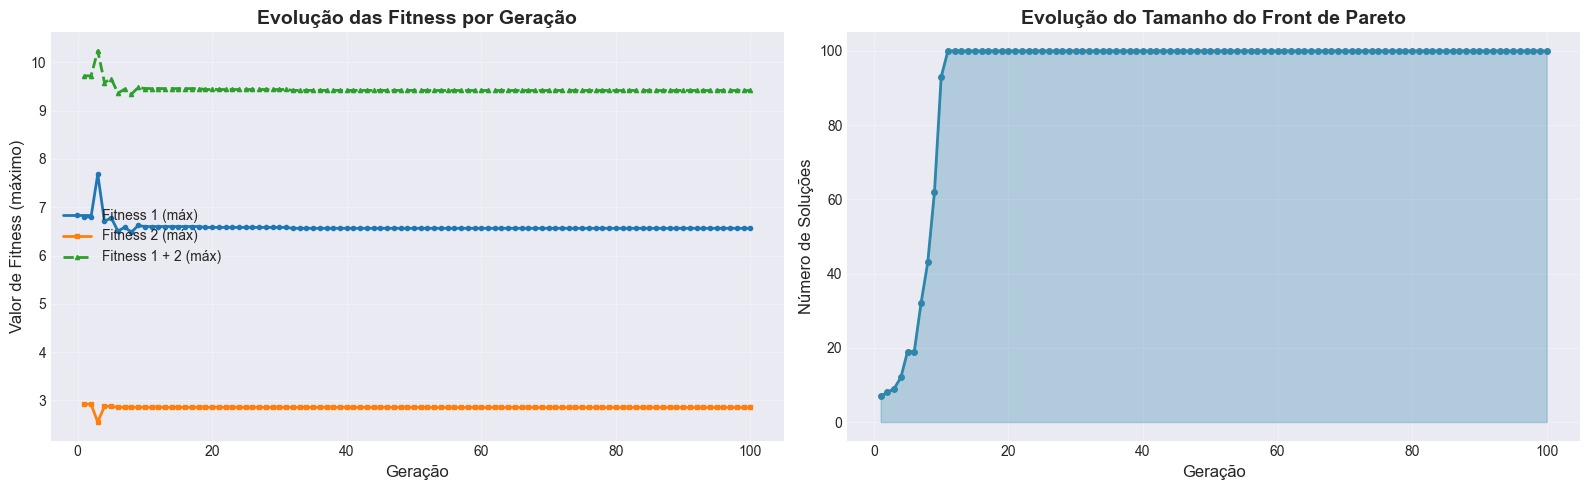


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:09<00:00,  1.43it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


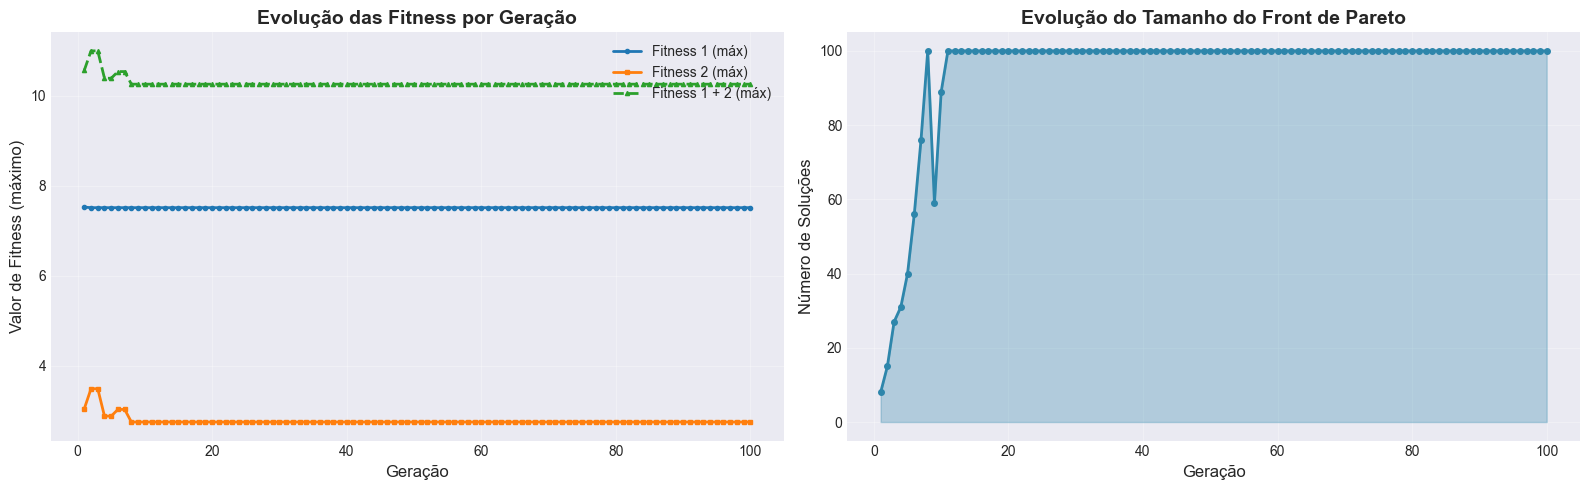


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:25<00:00,  1.17it/s]


✅ Otimização concluída!
Soluções únicas no front de Pareto: 100


In [9]:
### NSGA2 - Original
config['n_generations'] = 100

df_bbob16_aux = df_bbob16_previsao.copy()
df_bbob16_aux['fitness1'] = df_bbob16_aux['f1_original']
df_bbob16_aux['fitness2'] = df_bbob16_aux['f2_original']

df_pareto_my, _, _ = run_my_nsga2(config, df_bbob16_aux)
df_pareto_my['f1'] = df_pareto_my['f1_original']
df_pareto_my['f2'] = df_pareto_my['f2_original']


### NSGA2 - Surrogate
df_bbob16_aux = df_bbob16_previsao.copy()
df_bbob16_aux['fitness1'] = df_bbob16_aux['f1_predicted']
df_bbob16_aux['fitness2'] = df_bbob16_aux['f2_predicted']

df_pareto_my2, _, _ = run_my_nsga2(config, df_bbob16_aux)
df_pareto_my2['f1'] = df_pareto_my2['f1_original']
df_pareto_my2['f2'] = df_pareto_my2['f2_original']


### UA-SA-NSGA2
config['utiliza_ds_niching'] = False
df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape_bbob16, save_history=True)
df_pareto_ua_sa.drop_duplicates(subset=['x_1_landscape', 'x_2_landscape'], inplace=True)
df_pareto_ua_sa = (df_pareto_ua_sa[['x_1_landscape', 'x_2_landscape', 'f1_original', 'f2_original']].
                            rename(columns={'x_1_landscape': 'x_1', 
                                            'x_2_landscape': 'x_2', 
                                            'f1_original': 'f1', 
                                            'f2_original': 'f2'
                                   })
)

In [10]:
display(df_pareto_ua_sa.head(3))
display(df_pareto_my.head(3))
display(df_pareto_my2.head(3))

df_pareto_bbob16 = find_pareto_front(df_bbob16, minimize=True, fitness1='f1', fitness2='f2')
display(df_pareto_bbob16.head(3))

,x_1,x_2,f1,f2
0,-1.676677,-3.828829,0.624281,3.076795
1,-1.656657,-3.828829,0.636841,3.075337
2,-1.676677,-3.808809,0.562109,3.054647


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,-3.693441,0.073510,6.563362,0.100000,-3.688689,0.065065,6.563362,0.100000,6.563362,0.100000,6.471224,0.810452,True
1,-3.693441,0.073510,6.563362,0.100000,-3.688689,0.065065,6.563362,0.100000,6.563362,0.100000,6.471224,0.810452,True
2,-1.523404,-3.528221,0.100267,2.854049,-1.516517,-3.528529,0.100267,2.854049,0.100267,2.854049,1.561966,2.544689,True


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,-0.055322,3.658800,7.515027,0.007513,-0.055055,3.658659,7.905818,1.157842,7.905818,1.157842,7.515027,0.007513,True
1,-0.045196,3.674451,7.515027,0.007513,-0.045045,3.668669,7.909089,1.189451,7.909089,1.189451,7.515027,0.007513,True
2,-1.645936,-3.817422,-1.141514,2.746875,-1.646647,-3.818819,0.610588,3.063107,0.610588,3.063107,-1.141514,2.746875,True


Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 719 pontos.
Isso representa 0.0719% do espaço de busca.


,x_1,x_2,f1,f2,aux
146347,-1.526527,-3.538539,0.100000,2.857431,1
147348,-1.516517,-3.528529,0.100267,2.854049,1
147349,-1.506507,-3.528529,0.101310,2.852445,1


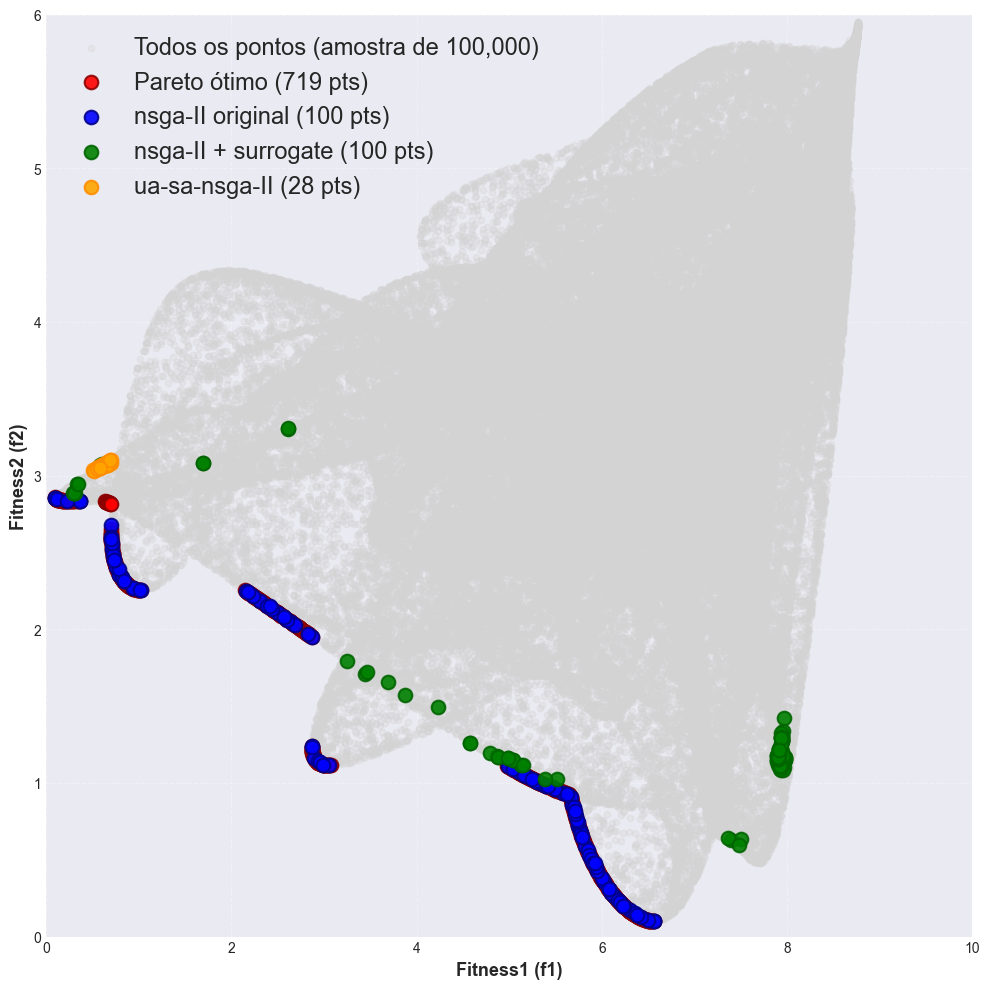

In [11]:
# Plota fronteira de Pareto real
fig_front = display_pareto_fronts3(df_bbob16, 
                                  [df_pareto_bbob16, df_pareto_my, df_pareto_my2, df_pareto_ua_sa], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=['Pareto ótimo', 'nsga-II original', 'nsga-II + surrogate', 'ua-sa-nsga-II'], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')

#### processamento original + gifs

In [12]:
#df_pareto_real = find_pareto_front(df_bbob16, minimize=True, fitness1='f1', fitness2='f2')
#
#df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
##df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
#df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]
##df_pareto_ua_sa_p40 = df[df.registro.isin(df_pareto_ua_sa_p40.registro.unique())]
##df_pareto_ua_sa_ds_niching = df[df.registro.isin(df_pareto_ua_sa_ds_niching.registro.unique())]
#
## convergencia entre resultados
#fig = display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa],#, df_pareto_ua_sa_p40],
#                       front_names=['Pareto Real', 'NSGA-II', 'UA-SA-NSGA-II'], sample_size=1000000,
#                       front_colors=['red', 'blue', 'orange'])
#fig.savefig('data/figures/nb5_pareto_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#fig_landscape_p1 = display_fitness_landscape_with_paretos(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa], 
#                                                          front_colors=['red', 'blue', 'orange'], 
#                                                          n_regioes=5, show_error_subplot=True)
#fig_landscape_p1.savefig('data/figures/nb5_landscape_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#print('===================== UA-SA-NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_ua_sa)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_delta_metric(delta_results)
#
##print('===================== gamma ua-sa-nsga2 (percentil 40) =====================')
##gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa_p40)
##print_gamma_metric(gamma_results)
#
##print('===================== gamma ua-sa-nsga2 com niching =====================')
##gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa_ds_niching)
##print_gamma_metric(gamma_results)
#
#print('\n===================== NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_my)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_my)
#print_delta_metric(delta_results)

In [13]:
#if salva_gifs:
#    # Gerar GIF com a evolução das populações
#    caminho_gif = gerar_gif_evolucao_nsga2(
#        df_landscape=df,  # Mesmo dataframe usado acima
#        history=history,
#        nome_arquivo='gif_pareto_p1.gif',
#        fps=5,  # Ajuste a velocidade conforme preferir
#        output_dir='data/gifs'
#    )
#
#    print(f"GIF salvo em: {caminho_gif}")


#    # Gerar GIF com a evolução das populações
#    caminho_gif = gerar_gif_evolucao_nsga2(
#        df_landscape=df,  # Mesmo dataframe usado acima
#        history=history_niching,
#        nome_arquivo='gif_pareto_p1_ds_niching.gif',
#        fps=5,  # Ajuste a velocidade conforme preferir
#        output_dir='data/gifs'
#    )
#
#    print(f"GIF salvo em: {caminho_gif}")

In [14]:
#df_history = history_to_dataframe(history).drop(columns=['id_solucao'])
#df_history = df_history.sort_values(by=['geracao','genotipo'])
#df_history['id_solucao'] = df_history.groupby(['geracao']).cumcount() + 1
#display_evolution_of_genotypes(df_history)

In [15]:
#df_history = history_to_dataframe(history_niching).drop(columns=['id_solucao'])
#df_history = df_history.sort_values(by=['geracao','genotipo'])
#df_history['id_solucao'] = df_history.groupby(['geracao']).cumcount() + 1
#display_evolution_of_genotypes(df_history)

#### melhores solucoes

In [16]:
#df_pareto_my, _, _, _  = run_my_nsga2(config, df_predicted)
#
#config['n_generations'] = 40
#config['utiliza_ds_niching'] = False
#df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape1, save_history=True)

#config['n_generations'] = 56
#config['utiliza_ds_niching'] = True
#df_pareto_ua_sa_ds_niching, history_niching = run_my_uasa_nsga2(config, df_landscape1, save_history=True)

In [17]:
#df_pareto_real = find_pareto_front(df)
#
#df_pareto_real = df[df.registro.isin(df_pareto_real.registro.unique())]
#df_pareto_my = df[df.registro.isin(df_pareto_my.registro.unique())]
#df_pareto_ua_sa = df[df.registro.isin(df_pareto_ua_sa.registro.unique())]
##df_pareto_ua_sa_ds_niching = df[df.registro.isin(df_pareto_ua_sa_ds_niching.registro.unique())]
#
## convergencia entre resultados
#fig = display_pareto_fronts3(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa],#, df_pareto_ua_sa_ds_niching], 
#                       front_names=['Pareto Real', 'NSGA-II', 'UA-SA-NSGA-II'], sample_size=1000000,
#                       front_colors=['red', 'blue', 'orange'])
#fig.savefig('data/figures/nb5_pareto_best_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#fig_landscape_p1_best = display_fitness_landscape_with_paretos(df, [df_pareto_real, df_pareto_my, df_pareto_ua_sa], 
#                                                               front_colors=['red', 'blue', 'orange'], 
#                                                               n_regioes=5, show_error_subplot=True)
#fig_landscape_p1_best.savefig('data/figures/nb5_landscape_best_ua_saea_problema1.jpg', dpi=150, bbox_inches='tight')
#
#print('===================== UA-SA-NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_ua_sa)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_ua_sa)
#print_delta_metric(delta_results)
#
##print('===================== gamma ua-sa-nsga2 com niching =====================')
##gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_ua_sa_ds_niching)
##print_gamma_metric(gamma_results)
#
#print('\n===================== NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_my)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df, df_pareto_my)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df, df_pareto_real, df_pareto_my)
#print_delta_metric(delta_results)

#### Landscape Previsto

In [18]:
#df_pareto_real = find_pareto_front(df_predicted)
#
#df_pareto_real = df_predicted[df_predicted.registro.isin(df_pareto_real.registro.unique())]
#df_pareto_my = df_predicted[df_predicted.registro.isin(df_pareto_my.registro.unique())]
#df_pareto_ua_sa = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa.registro.unique())]
##df_pareto_ua_sa_ds_niching = df_predicted[df_predicted.registro.isin(df_pareto_ua_sa_ds_niching.registro.unique())]
#
## convergencia entre resultados
#fig = display_pareto_fronts3(df_predicted, [df_pareto_real, df_pareto_my, df_pareto_ua_sa],#, df_pareto_ua_sa_ds_niching],
#                       front_names=['Pareto Surrogate', 'NSGA-II', 'UA-SA-NSGA-II'], sample_size=1000000,
#                       front_colors=['red', 'blue', 'orange'])
#
#
#print('===================== UA-SA-NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df_predicted, df_pareto_ua_sa)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df_predicted, df_pareto_real, df_pareto_ua_sa)
#print_delta_metric(delta_results)
#
#print('\n===================== NSGA-II =====================')
#gamma_results = calculate_gamma_convergence_metric(df_predicted, df_pareto_real, df_pareto_my)
#print_gamma_metric(gamma_results)
#
#fitness_sum_results = calculate_fitness_sum_statistics(df_predicted, df_pareto_my)
#print_fitness_sum_statistics(fitness_sum_results)
#
#delta_results = calculate_delta_diversity_metric(df_predicted, df_pareto_real, df_pareto_my)
#print_delta_metric(delta_results)

# MMF4

In [19]:
config['limite_inferior'] = np.array([-1, 0])
config['limite_superior'] = np.array([ 1, 2])

In [20]:
decision_variables = ['x_1', 'x_2']

df_landscape_mmf4 = create_landscape_from_predictions(
    df_previsao=df_mmf4_previsao,
    df_mcmc=df_mcmc_mmf4,
    decision_variables=decision_variables
)

print(df_landscape_mmf4.shape)
df_landscape_mmf4

(999504, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,-1.0,0.000000,0.992287,-0.224668,1.0,2.960407e-31,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."
1,-1.0,0.002002,0.931919,-0.229068,1.0,7.911394e-05,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."
2,-1.0,0.004004,1.182322,0.331255,1.0,3.164433e-04,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."
3,-1.0,0.006006,0.956288,0.370965,1.0,7.119504e-04,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."
4,-1.0,0.008008,0.926453,-0.308957,1.0,1.265573e-03,0.875836,0.564953,"[0.813, 0.914, 1.101, 0.725, 0.985, 1.008, 0.8...","[-0.118, 0.341, 1.598, 0.287, 1.847, 2.31, 0.8..."
...,...,...,...,...,...,...,...,...,...,...
999499,1.0,1.991992,1.100601,-0.330231,1.0,1.265573e-03,0.904907,2.559179,"[1.098, 0.831, 1.112, 0.824, 0.705, 0.932, 1.0...","[2.543, 2.021, 2.105, 3.143, 1.493, 3.143, 2.7..."
999500,1.0,1.993994,1.100601,-0.330785,1.0,7.119504e-04,0.904907,2.559179,"[1.098, 0.831, 1.112, 0.824, 0.705, 0.932, 1.0...","[2.543, 2.021, 2.105, 3.143, 1.493, 3.143, 2.7..."
999501,1.0,1.995996,1.100601,-0.331180,1.0,3.164433e-04,0.904907,2.559179,"[1.098, 0.831, 1.112, 0.824, 0.705, 0.932, 1.0...","[2.543, 2.021, 2.105, 3.143, 1.493, 3.143, 2.7..."
999502,1.0,1.997998,0.900398,-0.331418,1.0,7.911394e-05,0.904907,2.559179,"[1.098, 0.831, 1.112, 0.824, 0.705, 0.932, 1.0...","[2.543, 2.021, 2.105, 3.143, 1.493, 3.143, 2.7..."


100%|██████████| 100/100 [01:03<00:00,  1.58it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


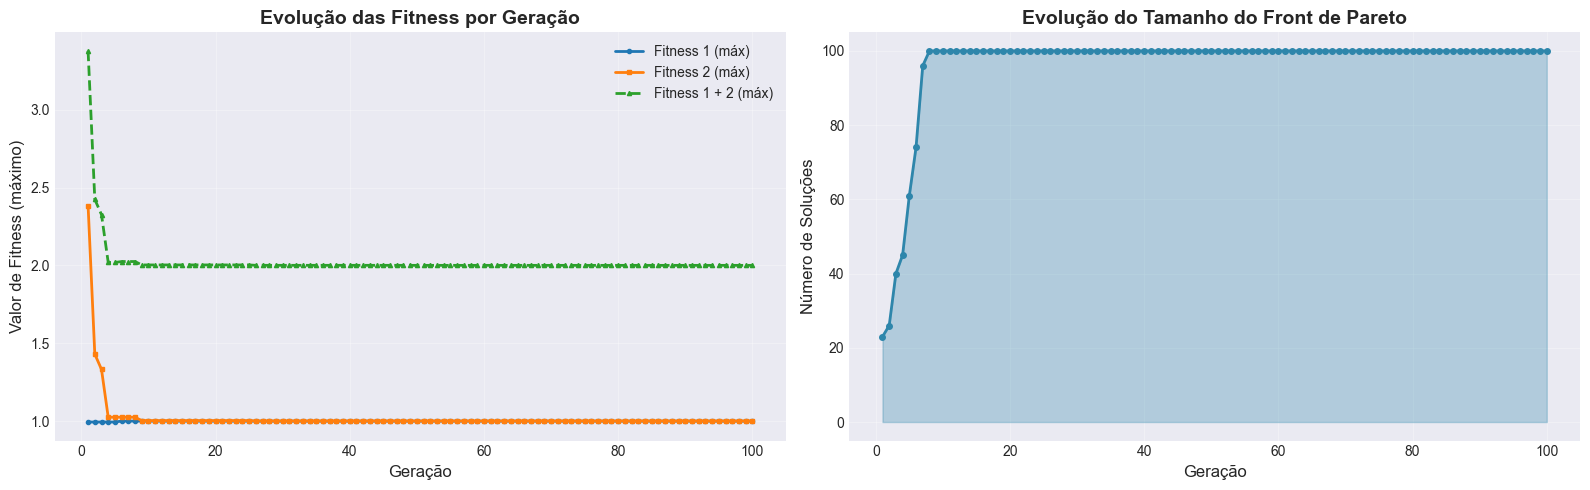


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:05<00:00,  1.53it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


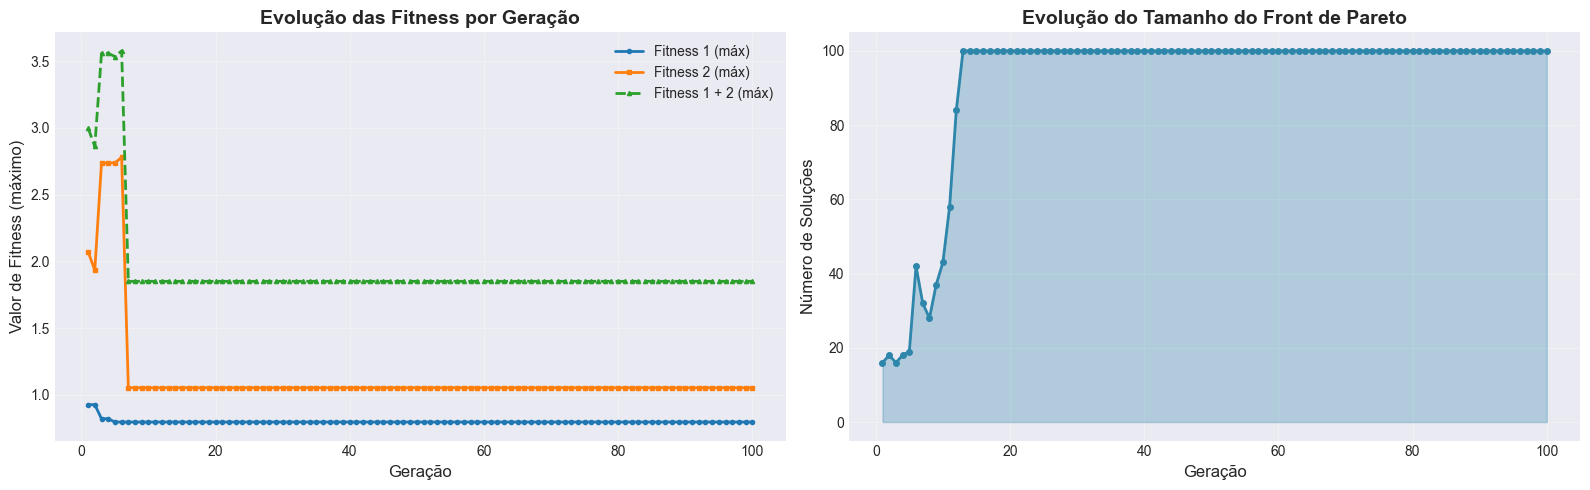


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:28<00:00,  1.13it/s]


✅ Otimização concluída!
Soluções únicas no front de Pareto: 100


In [21]:
### NSGA2 - Original
config['n_generations'] = 100

df_mmf4_aux = df_mmf4_previsao.copy()
df_mmf4_aux['fitness1'] = df_mmf4_aux['f1_original']
df_mmf4_aux['fitness2'] = df_mmf4_aux['f2_original']

df_pareto_my, _, _ = run_my_nsga2(config, df_mmf4_aux)
df_pareto_my['f1'] = df_pareto_my['f1_original']
df_pareto_my['f2'] = df_pareto_my['f2_original']


### NSGA2 - Surrogate
df_mmf4_aux = df_mmf4_previsao.copy()
df_mmf4_aux['fitness1'] = df_mmf4_aux['f1_predicted']
df_mmf4_aux['fitness2'] = df_mmf4_aux['f2_predicted']

df_pareto_my2, _, _ = run_my_nsga2(config, df_mmf4_aux)
df_pareto_my2['f1'] = df_pareto_my2['f1_original']
df_pareto_my2['f2'] = df_pareto_my2['f2_original']


### UA-SA-NSGA2
config['utiliza_ds_niching'] = False
df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape_mmf4, save_history=True)
df_pareto_ua_sa.drop_duplicates(subset=['x_1_landscape', 'x_2_landscape'], inplace=True)
df_pareto_ua_sa = (df_pareto_ua_sa[['x_1_landscape', 'x_2_landscape', 'f1_original', 'f2_original']].
                            rename(columns={'x_1_landscape': 'x_1', 
                                            'x_2_landscape': 'x_2', 
                                            'f1_original': 'f1', 
                                            'f2_original': 'f2'
                                   })
)

In [22]:
display(df_pareto_ua_sa.head(3))
display(df_pareto_my.head(3))
display(df_pareto_my2.head(3))

df_pareto_mmf4 = find_pareto_front(df_mmf4, minimize=True, fitness1='f1', fitness2='f2')
display(df_pareto_mmf4.head(3))

,x_1,x_2,f1,f2
0,0.125125,0.406406,0.125125,0.995096


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,-0.995878,1.002364,1.000000,0.000178,-1.000000,0.996997,1.000000,0.000178,1.000000,0.000178,0.971213,1.049982,True
1,-0.995878,1.002364,1.000000,0.000178,-1.000000,0.996997,1.000000,0.000178,1.000000,0.000178,0.971213,1.049982,True
2,-0.003002,1.008011,0.003003,1.000378,-0.003003,1.005005,0.003003,1.000378,0.003003,1.000378,0.026242,2.101094,True


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,0.904767,0.082060,0.797185,-0.295595,0.895896,0.076076,0.895896,1.167073,0.895896,1.167073,0.797185,-0.295595,True
1,0.899891,0.073684,0.797185,-0.295595,0.895896,0.066066,0.895896,1.229957,0.895896,1.229957,0.797185,-0.295595,True
2,0.014226,0.129858,-0.110765,1.054042,0.005005,0.126126,0.005005,1.231079,0.005005,1.231079,-0.110765,1.054042,True


Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 1,019 pontos.
Isso representa 0.1019% do espaço de busca.


,x_1,x_2,f1,f2,aux
501499,-0.001001,1.003003,0.001001,0.999999,1
501500,0.001001,1.003003,0.001001,0.999999,1
504498,-0.003003,1.009009,0.003003,0.999995,1


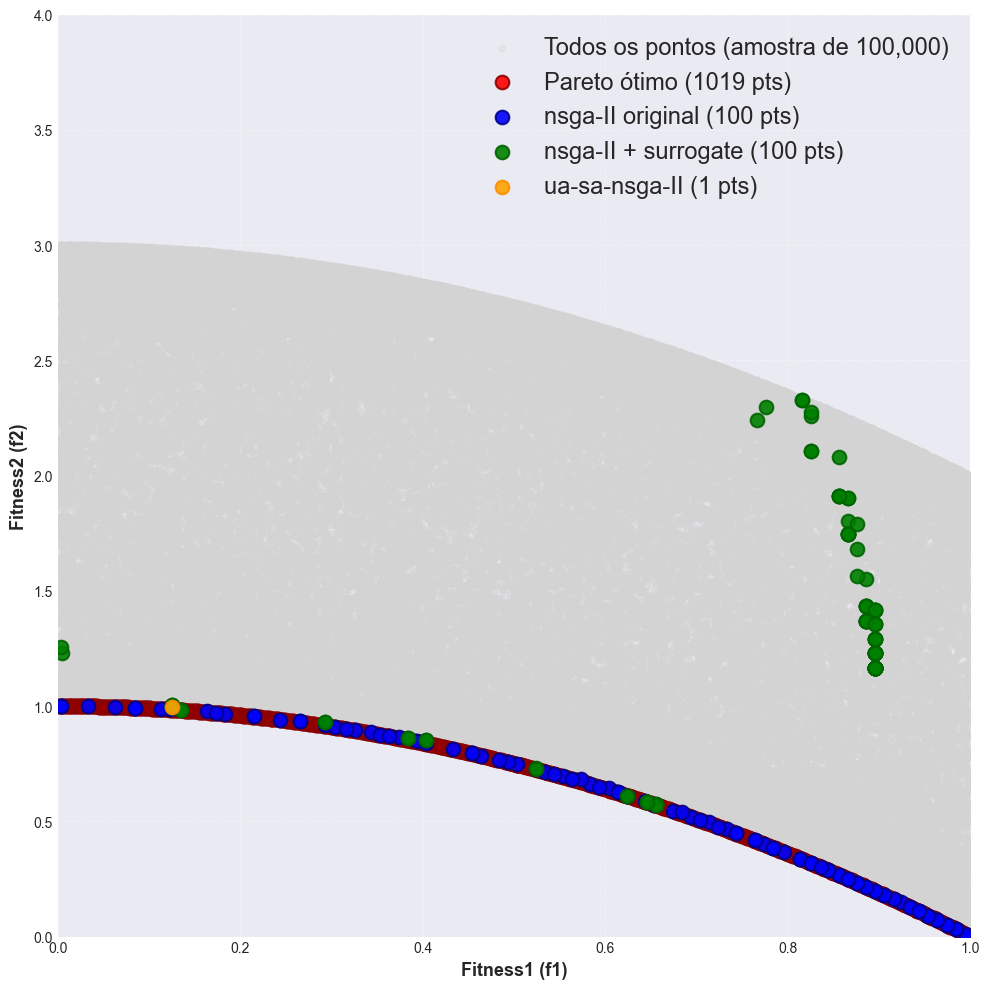

In [23]:
# Plota fronteira de Pareto real
fig_front = display_pareto_fronts3(df_mmf4, 
                                  [df_pareto_mmf4, df_pareto_my, df_pareto_my2, df_pareto_ua_sa], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=['Pareto ótimo', 'nsga-II original', 'nsga-II + surrogate', 'ua-sa-nsga-II'], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')

# MMF1

In [24]:
config['limite_inferior'] = np.array([1, -1])
config['limite_superior'] = np.array([3,  1])

In [25]:
decision_variables = ['x_1', 'x_2']

df_landscape_mmf1 = create_landscape_from_predictions(
    df_previsao=df_mmf1_previsao,
    df_mcmc=df_mcmc_mmf1,
    decision_variables=decision_variables
)

print(df_landscape_mmf1.shape)
df_landscape_mmf1

(999504, 10)


,x_1,x_2,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,fitness1,fitness2
0,1.0,-1.000000,0.992287,1.730255,1.0,2.000000,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."
1,1.0,-0.997998,0.931919,1.716878,1.0,1.992000,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."
2,1.0,-0.995996,1.182322,2.381354,1.0,1.984016,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."
3,1.0,-0.993994,0.956288,2.420588,1.0,1.976048,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."
4,1.0,-0.991992,0.926453,1.595631,1.0,1.968096,0.875836,2.484513,"[0.778, 0.862, 1.018, 0.728, 1.138, 1.087, 0.8...","[4.255, 4.863, 4.37, 2.033, 4.855, 6.498, 3.34..."
...,...,...,...,...,...,...,...,...,...,...
999499,3.0,0.991992,1.100601,1.570089,1.0,1.968096,0.904907,1.358528,"[1.098, 0.831, 1.112, 0.824, 0.705, 0.932, 1.0...","[1.537, 0.87, 2.763, 0.82, -0.419, 1.69, 3.155..."
999500,3.0,0.993994,1.100601,1.578041,1.0,1.976048,0.904907,1.358528,"[1.098, 0.831, 1.112, 0.824, 0.705, 0.932, 1.0...","[1.537, 0.87, 2.763, 0.82, -0.419, 1.69, 3.155..."
999501,3.0,0.995996,1.100601,1.586009,1.0,1.984016,0.904907,1.358528,"[1.098, 0.831, 1.112, 0.824, 0.705, 0.932, 1.0...","[1.537, 0.87, 2.763, 0.82, -0.419, 1.69, 3.155..."
999502,3.0,0.997998,0.900398,1.593993,1.0,1.992000,0.904907,1.358528,"[1.098, 0.831, 1.112, 0.824, 0.705, 0.932, 1.0...","[1.537, 0.87, 2.763, 0.82, -0.419, 1.69, 3.155..."


100%|██████████| 100/100 [01:06<00:00,  1.50it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


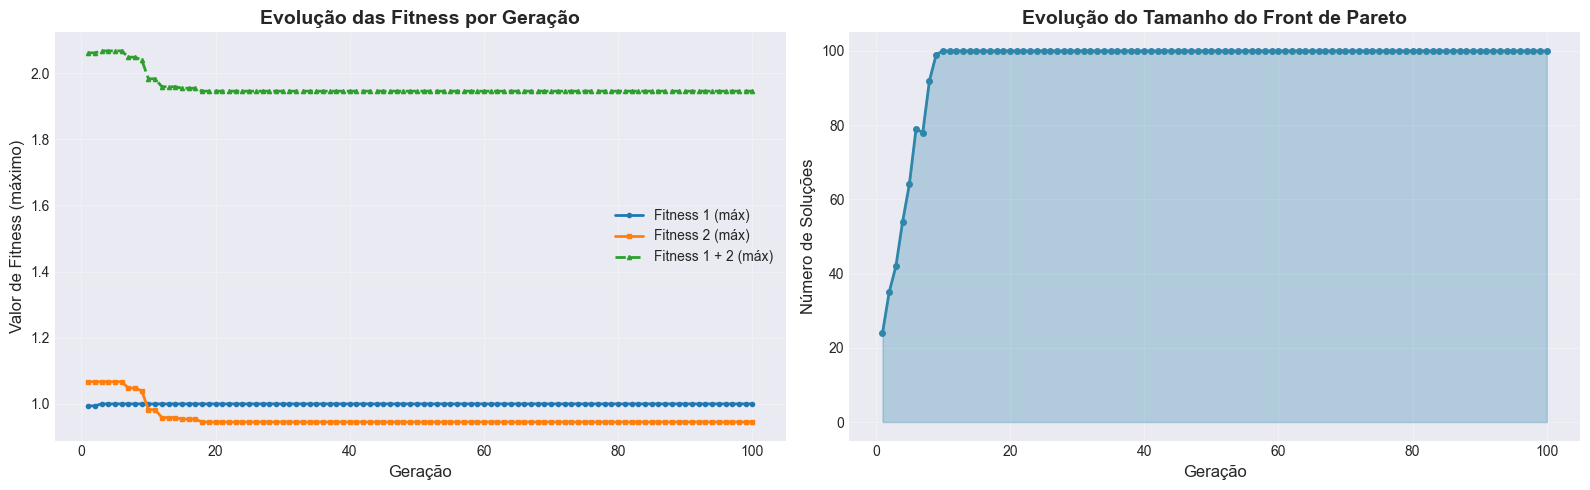


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:07<00:00,  1.47it/s]


✅ Otimização concluída!
Registros únicos no dataframe: 100


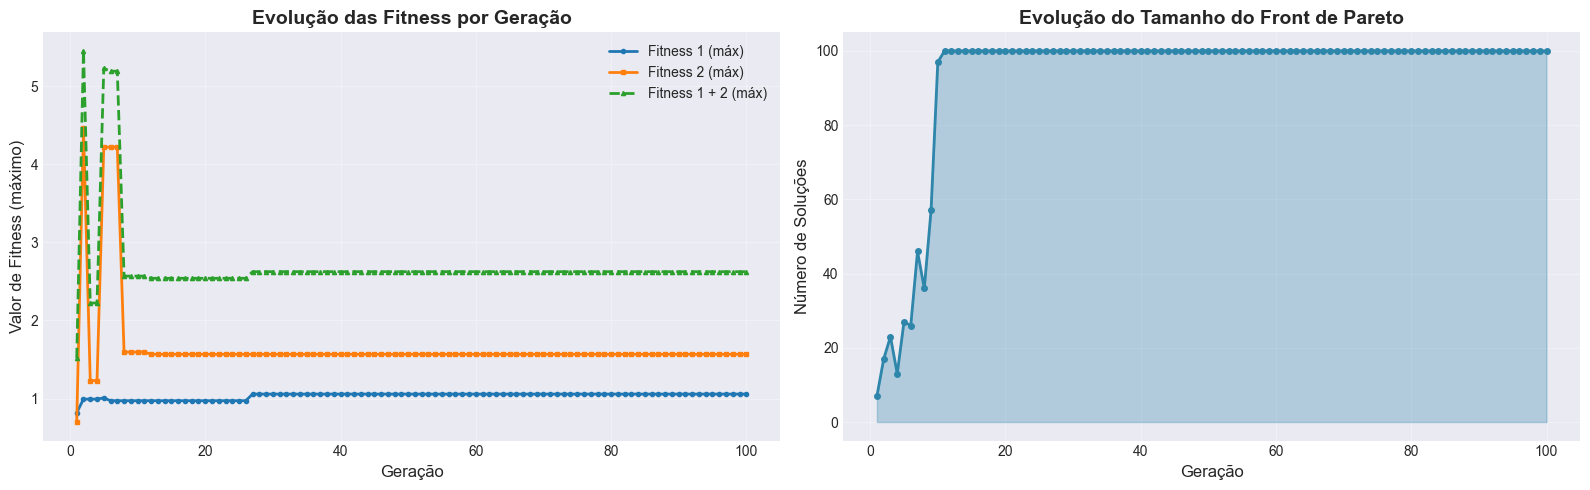


✅ Gráficos de progresso gerados com sucesso!


100%|██████████| 100/100 [01:49<00:00,  1.10s/it]


✅ Otimização concluída!
Soluções únicas no front de Pareto: 100


In [26]:
### NSGA2 - Original
config['n_generations'] = 100

df_mmf1_aux = df_mmf1_previsao.copy()
df_mmf1_aux['fitness1'] = df_mmf1_aux['f1_original']
df_mmf1_aux['fitness2'] = df_mmf1_aux['f2_original']

df_pareto_my, _, _ = run_my_nsga2(config, df_mmf1_aux)
df_pareto_my['f1'] = df_pareto_my['f1_original']
df_pareto_my['f2'] = df_pareto_my['f2_original']


### NSGA2 - Surrogate
df_mmf1_aux = df_mmf1_previsao.copy()
df_mmf1_aux['fitness1'] = df_mmf1_aux['f1_predicted']
df_mmf1_aux['fitness2'] = df_mmf1_aux['f2_predicted']

df_pareto_my2, _, _ = run_my_nsga2(config, df_mmf1_aux)
df_pareto_my2['f1'] = df_pareto_my2['f1_original']
df_pareto_my2['f2'] = df_pareto_my2['f2_original']


### UA-SA-NSGA2
config['utiliza_ds_niching'] = False
df_pareto_ua_sa, history = run_my_uasa_nsga2(config, df_landscape_mmf1, save_history=True)
df_pareto_ua_sa.drop_duplicates(subset=['x_1_landscape', 'x_2_landscape'], inplace=True)
df_pareto_ua_sa = (df_pareto_ua_sa[['x_1_landscape', 'x_2_landscape', 'f1_original', 'f2_original']].
                            rename(columns={'x_1_landscape': 'x_1', 
                                            'x_2_landscape': 'x_2', 
                                            'f1_original': 'f1', 
                                            'f2_original': 'f2'
                                   })
)

In [27]:
display(df_pareto_ua_sa.head(3))
display(df_pareto_my.head(3))
display(df_pareto_my2.head(3))

df_pareto_mmf1 = find_pareto_front(df_mmf1, minimize=True, fitness1='f1', fitness2='f2')
display(df_pareto_mmf1.head(3))

,x_1,x_2,f1,f2
0,1.986987,-0.193193,0.013013,0.890854
1,1.966967,-0.203203,0.033033,1.107040
3,1.976977,-0.183183,0.023023,0.960886


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,1.002303,0.001873,1.000000,0.000018,1.000000,-0.003003,1.000000,0.000018,1.000000,0.000018,0.971213,0.388738,True
1,1.002303,0.001873,1.000000,0.000018,1.000000,-0.003003,1.000000,0.000018,1.000000,0.000018,0.971213,0.388738,True
2,2.004014,-0.052723,0.003003,0.945225,1.996997,-0.053053,0.003003,0.945225,0.003003,0.945225,0.034462,0.982117,True


,x_1,x_2,fitness1,fitness2,x_1_landscape,x_2_landscape,f1,f2,f1_original,f2_original,f1_predicted,f2_predicted,mapping_success
0,2.999793,0.422464,1.057186,-0.475781,2.995996,0.415415,0.995996,0.233222,0.995996,0.233222,1.057186,-0.475781,True
1,3.000000,0.423488,1.057186,-0.475781,2.995996,0.415415,0.995996,0.233222,0.995996,0.233222,1.057186,-0.475781,True
2,2.010647,-0.871642,-0.110765,1.566843,2.005005,-0.873874,0.005005,2.145030,0.005005,2.145030,-0.110765,1.566843,True


Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 1,000 pontos.
Isso representa 0.1000% do espaço de busca.


,x_1,x_2,f1,f2,aux
490499,1.998999,-0.019019,0.001001,0.968361,1
490500,2.001001,-0.019019,0.001001,0.968361,1
471501,2.003003,-0.057057,0.003003,0.945201,1


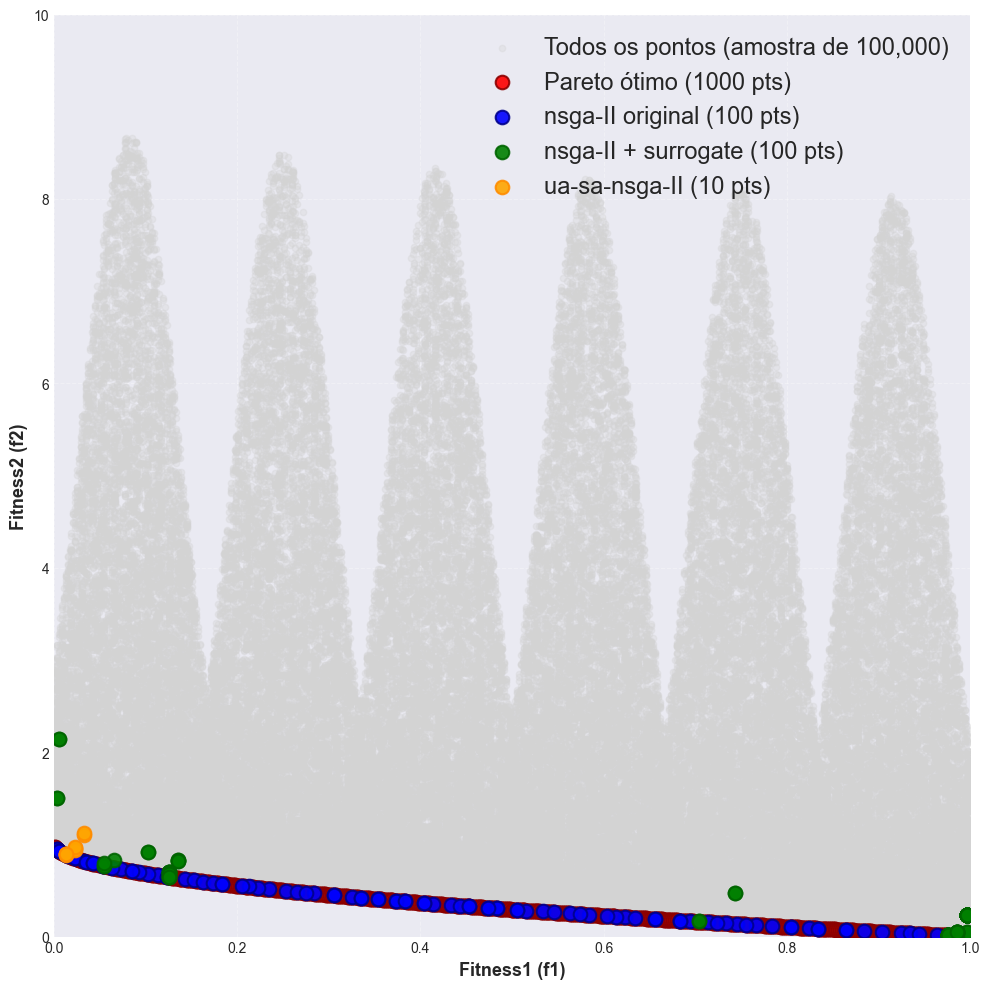

In [28]:
# Plota fronteira de Pareto real
fig_front = display_pareto_fronts3(df_mmf1, 
                                  [df_pareto_mmf1, df_pareto_my, df_pareto_my2, df_pareto_ua_sa], 
                                   fitness1='f1', fitness2='f2', 
                                   front_names=['Pareto ótimo', 'nsga-II original', 'nsga-II + surrogate', 'ua-sa-nsga-II'], 
                                   sample_size=100_000)
#fig_front.savefig('data/figures/nb1_front_verdadeiro_problema1.jpg', dpi=150, bbox_inches='tight')